# Using Hadamards and T-gates in Topologiq

In [2]:
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

This notebook offers an example of how to use ***Topologiq*** to perform an algorithmic lattice surgery of a PyZX graph that includes Hadamards and T-gates.

The process requires a PyZX input graph that allows computing Pauli webs.

## PyZX

For this notebook, we will be using a PyZX graph used in a notebook where Alex Kissinger demonstrates usage of Pauli webs in PyZX. 

It is not too small nor too large to deal with in a notebook, and has the structure needed for compatibility with Topologiq.

In [3]:
import random
import pyzx as zx
zx.settings.colors = zx.rgb_colors

# Give circuit a legendary name
random.seed(1330)
circuit_name = "Graphy_McGraphy"

# Generate a random CNOT, H, T circuit
c = zx.generate.CNOT_HAD_PHASE_circuit(qubits=3, depth=30)
pyzx_graph = c.to_graph(compress_rows=False)

# Unfuse the non-Clifford spiders, so they look like outputs measured in {|T>, Z|T>}
zx.simplify.gadgetize(pyzx_graph, graphlike=False)
zx.id_simp(pyzx_graph)

# Draw
zx.draw(pyzx_graph, labels=True)

We will not be giving Topologiq any Pauli webs directly. Topologiq needs Pauli webs to be computable because it computes them internally and uses them to create minimum and maximum time coordinates for certain blocks. 

So, as long as the graph can have Pauli webs, you can just give the graph to Topologiq. 

Having said that, it is a good idea to check the Pauli webs to understand a little why they are necessary.

Below the Pauli webs of this circuit, alongside a printout of the `order` object and a visualisation of an specific Pauli web.

You will notice by comparing the `order` and the visualisation that:
- T-gate 65 requires information from T-gates 51, 53, 55, meaning it cannot be handled prior in time than its preceding T-gates.
- The path to T-gates 51, 53, 55 includes many but not all spiders in a row prior to them.
- The path to 65 includes all spiders in the path to 51, 53, 55, and a few more.

All spiders (incl. T-gates) in the path to a T-gate must come before the particular T-gate, for all T-gates in circuit. In lattice surgery, this requires ensuring the BlockGraph equivalent objects of the T-gate happen after than all predecessors.

Topologiq handles this internally by computing Pauli webs and their `order` and then, for all Pauli webs, determining spiders that need to happen before other spiders. The joint set of spiders that need to happen before any arbitrary T-gate are encoded into an object that essentially sets the limits of where a T-gate can be placed in the Blockgraph.

> NB! This is a highly experimental feature, so nothing in this notebook should be interpreted as a guarantee of absence of errors. Please do flag up any errors or bugs encountered in any experiment. 


In [4]:
from pyzx.pauliweb import compute_pauli_webs

# Compute Pauli webs
order, zwebs, xwebs = compute_pauli_webs(pyzx_graph)

# Check `order`, which tells the order in which we should measure non-Clifford spiders.
print(order)

# Visualise one of the Pauli webs as example.
zx.draw(pyzx_graph, labels=True, pauli_web=zwebs[65])

{51: 1, 53: 1, 55: 1, 57: 1, 59: 2, 61: 2, 63: 2, 65: 2}


## Topologiq

Let's now go ahead and create what ***Topologiq*** calls a `BlockGraphManager`, which has metadata summarising the details of the original PyZX graph and a number of methods to assist the process of performing lattice surgery on the input ZX graph.

Additionally, for this particular graph, and, generally, any graph including T-gates, it is also necessary to add a couple fields to KWARGs:
- `"graph_traverse_mode": "bfs-cnots"`: A tree search rationale (queue) that facilitates management of time orderings involving T-gates and CNOTs/CZs.
- `"z_stretch": 4` *(or any integer)*: Weight to determine the strenght by which the graph is spread across the time dimension, which also helps facilitate management of time orderings involving T-gates and CNOTs/CZs.

Notice that the ZX graph changes slightly upon conversion into a `BlockGraphManager`. The spiders with pi/4 phase become a pattern of spiders with new colours. The specific lattice surgery pattern is discussed [in this slide deck by Austin Fowler](https://docs.google.com/presentation/d/184GHX9jffq9dcwWzbku0K90V9xdA8_25lD8pfeEcgRg/edit?usp=sharing). The pattern performs a logical T-gate. 

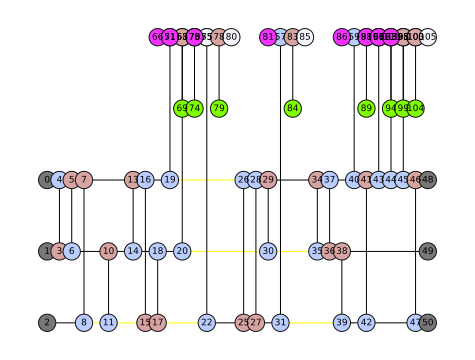

In [5]:
from topologiq.core.graph_manager.graph_manager import BlockGraphManager

# KWARGs
# You can opt NOT to include any "kwargs" whatsoever (Topologiq will auto-complete using defaults).
# You can feed specific "kwargs" into the BlockGraphManager to deviate from defaults.
# See `src/topologiq/kwargs.py` for all possible "kwarg" values (write them in lower case if you include manually).
kwargs = {
    "graph_traverse_mode": "tfs-cnots",
    "z_stretch": 3,
    "gravity": 3,
}

bgraph_manager = BlockGraphManager(pyzx_graph, **kwargs)
bgraph_manager.draw_zx()

It is now very easy to just ask ***Topologiq*** to perform lattice surgery on the input ZX graph using the recently created `BlockGraphManager`.

***Topologiq*** will traverse the graph using the selected BFS-cnots rationale, exchanging spiders and legs in the original PyZX graph for their BlockGraph-equivalent.
- Where possible, each spider will become ONE cube and each edge will become ONE pipe. 
- Due to the need to reach source and target cubes in a congested 3D space, topologiq may add any number of arbitrary spiders needed to clear a particular edge, as well as create twin cubes for some spiders. 

> NB. While effort has been put into ensuring the correctness of the resulting BlockGraph, we are far from a point were we would feel comfortable guaranteeing results. In particular, the examples and test cases have become too large for manual validation. As such, automated validation of equivalence between input ZX and output BlockGraphs is an area flagged as requiring significant attention in further research.

In [6]:
# Run Topolgiq
bgraph_manager.build()


SUCCESS! Habemus BlockGraph. Volume: 321. Duration: 36.61s



We can, of course, visualise results.

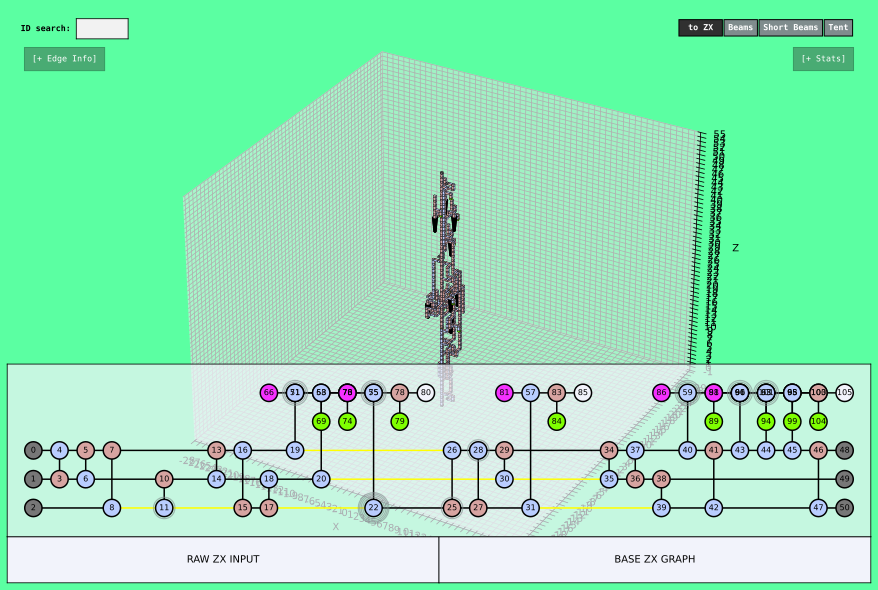

In [7]:
# Visualise results
bgraph_manager.draw_blockgraph()

And we can also confirm that all predecessors of a given T-gate do indeed happen before the specific T-gate.

For this, we can request the `bgraph_manager`'s `ante` attribute, a dictionary of all cubes with predecessors and their predecessors.
- Keys corresponds to the conditional cube in a given T-gate pattern, the specific cube in the pattern that must happen after predecessors.
- Values are lists with the IDs of all cubes that must come before the key.
- The coords of all cubes can be queried from the `bgraph_manager`'s `bgraph`, which holds the primary NX graph used during build.

In [8]:
# Print all cubes that must come before other cubes
time_oops = False
for k, v in bgraph_manager.ante.items():
    coords_of_conditional_cube = bgraph_manager.bgraph.nodes[k]["coords"]
    for cube_id in v:
        cube_coords = bgraph_manager.bgraph.nodes[cube_id]["coords"]
        if cube_coords[2] >= coords_of_conditional_cube[2]:
            time_oops = True
            print(f"Cube with ID {cube_id} happens AFTER conditional cube with ID {k}, which violates time constraints needed for successful computation.")

if not time_oops:
    print("#EPIC. No time-ordering violations detected.")

#EPIC. No time-ordering violations detected.


## Output

That's it! That's all it takes. 

To write result to file, just use the `bgraph_manager`'s `write_bgraph` method.

In [9]:
output_dir = os.path.join(repo_root, "output/bgraph")
bgraph_manager.write_bgraph(output_dir=output_dir, circuit_name=circuit_name)